### Data Innovation for Refugee Inclusion Hackathon - CA' Mazzu

Here we report the code that we used to reproduce the idea of our project. In particular we will use the same model as the current Cashy model, AutoGluon, but for a different purpose.

First, we import the needed library.

In [34]:
pip install autogluon.tabular
pip install shap

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from autogluon.tabular import TabularDataset, TabularPredictor
import shap


We import the dataset given

In [36]:
data = pd.read_csv("S8.synthetic_cashy_sample.csv", header = 0)

We noticed - and we were told - that the dataset is not representative of the motivation behind the inclusion or exclusion of a household, since it is missing a few variables.

However, here we assume that we can use it to train our model: specifically we divide the dataset leaving out 30 percent, and splitting the other 70 between train (50) and test (20).

From the dataset we leave out the month (the temporal dimension may confuse the model, since the randomization), the category of elegibility (it is the prediction we aim, but more detailed, so we kept only the binary version), the scores (Vulnerability , Demographics, NeedsandCoping) and Vulnerability_Category. These last excusions are motivated by the fact that they are a functionof the other variables. Our aim is to identify at the roots the important variables, and since these last carry information about other variables may skew the results.

In [37]:
# First, split the data to leave out 30%
data_70_percent, pseudo_new_data = train_test_split(
    data.drop(columns=['month', 'Elegibilidad', 'Vulnerability_Category', 'Demographics_Score', 'NeedsandCoping_Score', 'Vulnerability_Score', 'FinalScore']),
    test_size=0.3,
    stratify=data['EligibilityTarget'],
    random_state=42
)

# Now, split the 70% portion into training and testing sets for the model
# This means: 0.7 * 0.7 = 0.49 (49% of original for train), 0.7 * 0.3 = 0.21 (21% of original for test)

train_data, test_data = train_test_split(
    data_70_percent,
    test_size=0.3, # 30% of data_70_percent becomes the test set
    stratify=data_70_percent['EligibilityTarget'],
    random_state=42
)

print(f"Original data shape: {data.shape}")
print(f"Data held out (30%): {pseudo_new_data.shape}")
print(f"New sampled training data shape (50% of original): {train_data.shape}")
print(f"New sampled testing data shape (20% of original): {test_data.shape}")

Original data shape: (1900, 26)
Data held out (30%): (570, 19)
New sampled training data shape (50% of original): (931, 19)
New sampled testing data shape (20% of original): (399, 19)


Here, use tabular predictor to fit the model to the train dataset.

Next, predictor's performance is verified on the
test data.

Note that we verify the performance only to ensure that it is capable of reproducing the choice process that already took place.

In [81]:
# Initialize and train the TabularPredictor with the new, smaller sampled training data
predictor = TabularPredictor(label='EligibilityTarget', path='AutogluonModels_smaller_sampled',eval_metric='roc_auc').fit(train_data_smaller)

# Make predictions on the new, smaller sampled test data
predictions= predictor.predict(test_data)

# Evaluate the model's performance on the new, smaller sampled test data
performance = predictor.evaluate(test_data, silent=True)

print("AutoGluon predictions on new, smaller sampled test data:")
print(predictions.head())
print("\nAutoGluon model performance on new, smaller sampled test data:")
print(performance)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.34 GB / 12.67 GB (81.6%)
Disk Space Avail:   87.05 GB / 107.72 GB (80.8%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : Use this if you have a GPU. The go-to preset for best results, and the one to use for benchmark comparisons. New in v1.6: far better than 'best' on datasets <100000 samples by using Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: Nori, TabICLv2, an

AutoGluon predictions on new, smaller sampled test data:
493     EXCLUSION
1655    EXCLUSION
1761    EXCLUSION
1801    EXCLUSION
1734    EXCLUSION
Name: EligibilityTarget, dtype: object

AutoGluon model performance on new, smaller sampled test data:
{'roc_auc': np.float64(0.5193096008629989), 'accuracy': 0.7744360902255639, 'balanced_accuracy': np.float64(0.5118122977346279), 'mcc': np.float64(0.08113214809909995), 'f1': 0.0625, 'precision': 0.5, 'recall': 0.03333333333333333}


Now we extract the important features. These represent the most impactful variables on the fact that someone is included.

Together with the scale of importance we have a coefficient that measure it, a standard deviation and a p-value. The latter tells us whether the variable can be left out without significant change.



In [82]:
importance_df = predictor.feature_importance(data)

# This returns a Pandas DataFrame ranked from most important to least important
print(importance_df)

These features in provided data are not utilized by the predictor and will be ignored: ['month', 'Elegibilidad', 'Vulnerability_Category', 'Demographics_Score', 'NeedsandCoping_Score', 'Vulnerability_Score', 'FinalScore']
Computing feature importance via permutation shuffling for 18 features using 1900 rows with 5 shuffle sets...
	15.7s	= Expected runtime (3.14s per shuffle set)
	5.73s	= Actual runtime (Completed 5 of 5 shuffle sets)


                                importance    stddev       p_value  n  \
Needs_and_Coping.Housing          0.069211  0.008125  2.238234e-05  5   
Needs_and_Coping.Neg.mechanism    0.060311  0.008067  3.751490e-05  5   
Demographics.HH.Head              0.049723  0.009392  1.457492e-04  5   
Demographics.Profiles             0.048882  0.006793  4.362770e-05  5   
Needs_and_Coping.BasicNeeds       0.047281  0.006247  3.573821e-05  5   
OficinaACNUR                      0.035280  0.005266  5.783705e-05  5   
Demographics.Language             0.035109  0.003455  1.111331e-05  5   
Needs_and_Coping.Dependency       0.031807  0.002418  3.974489e-06  5   
dependencyCategory                0.030532  0.005960  1.657762e-04  5   
ScoreCOMAR_PIL                    0.023040  0.003307  4.956411e-05  5   
HablaEspanol                      0.022013  0.005443  4.141132e-04  5   
NumIntegrantes                    0.020900  0.002839  3.984794e-05  5   
FemaleHeadedHousehold             0.020656  0.00375

For this sample of our dataset, we obtained that the three most important variables are: Needs_and_Coping.Housing, Needs_and_Coping.Neg.mechanism and Demographics.HH.Head.

The value of the importance represents the drop in the 'performance' of the model when that feature is shuffled (ideally breaking any pre-existing logical connection in the data)

Then, we are able to, given a new data, to analyze which variables carry more weight in the evaluation of the new profile. We are using the library shap, that extract information directly from the AutoGluon model just trained.

In [75]:
Xx = pseudo_new_data.drop(columns=['EligibilityTarget'])
feature_names = Xx.columns

# Update the wrapper to convert SHAP's NumPy array back into a DataFrame
def ag_wrapper(X):
    df = pd.DataFrame(X, columns=feature_names)
    return predictor.predict_proba(df).values

background_data = Xx.sample(100, random_state=42)

# Initialize the explainer
explainer = shap.KernelExplainer(ag_wrapper, background_data)


Here we visualize, on ten different profiles taken from the left out data, their important features.

Red feature contribute positively to the evalutation of the risk while blue ones contributes negatively.

  0%|          | 0/1 [00:00<?, ?it/s]

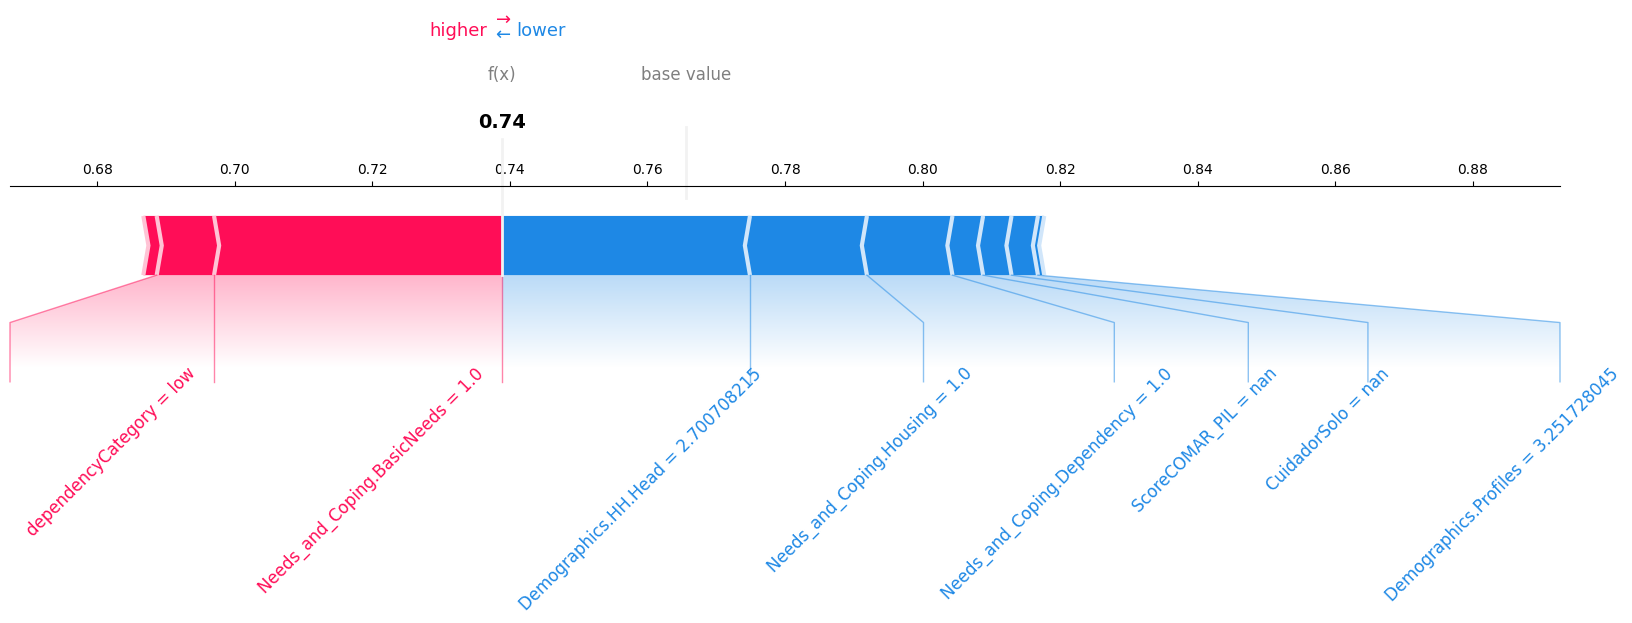

  0%|          | 0/1 [00:00<?, ?it/s]

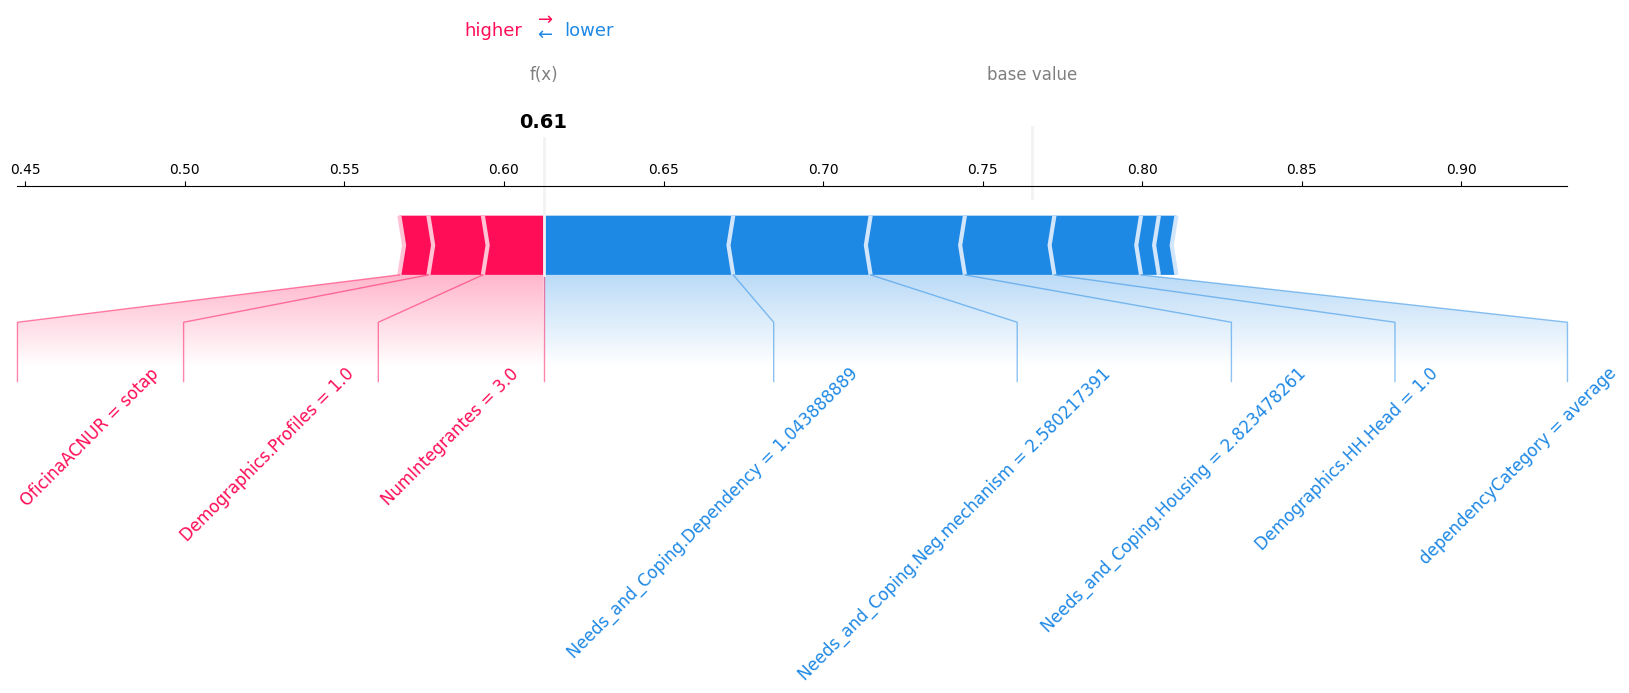

  0%|          | 0/1 [00:00<?, ?it/s]

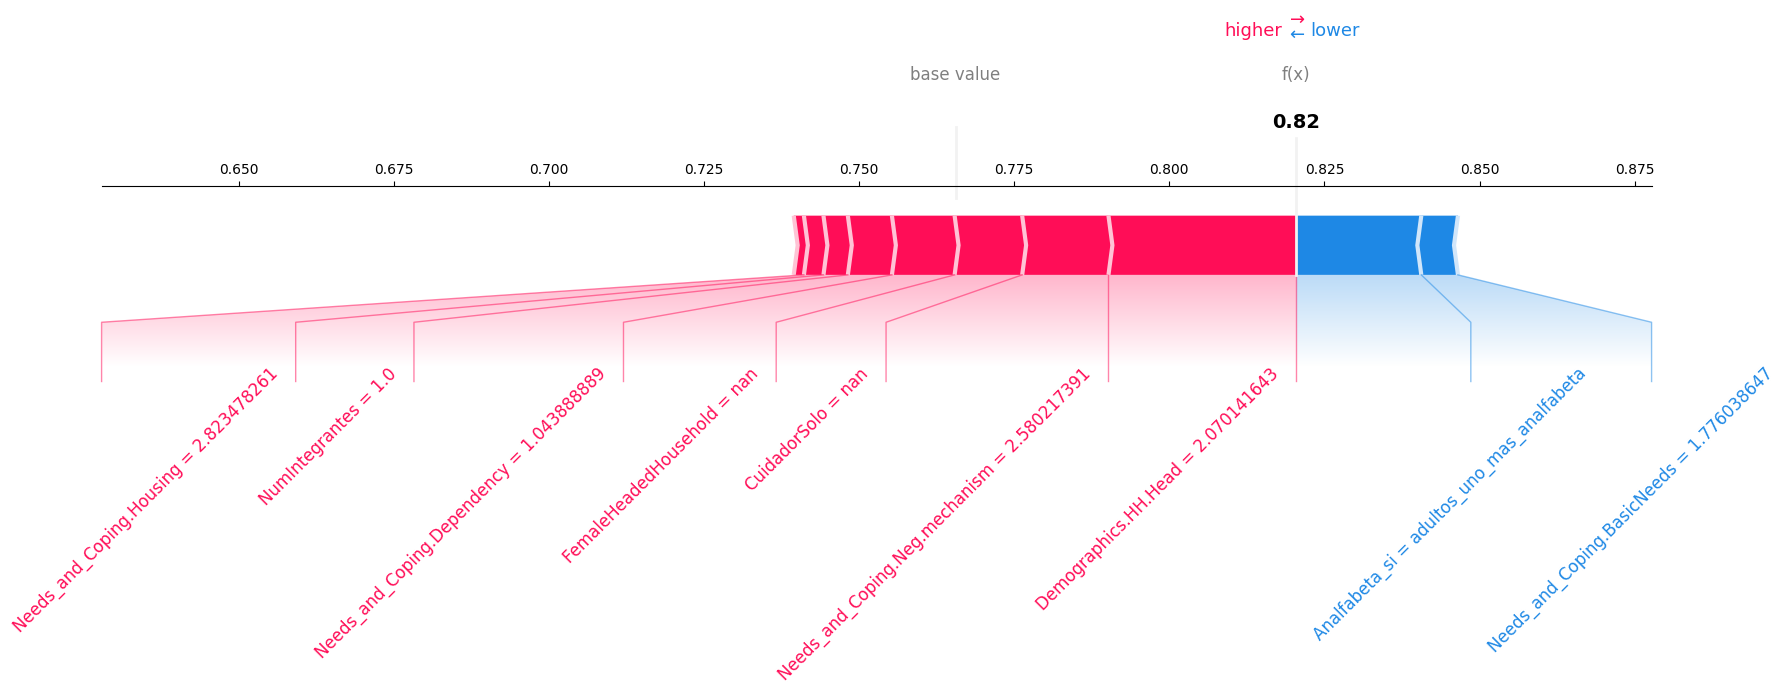

  0%|          | 0/1 [00:00<?, ?it/s]

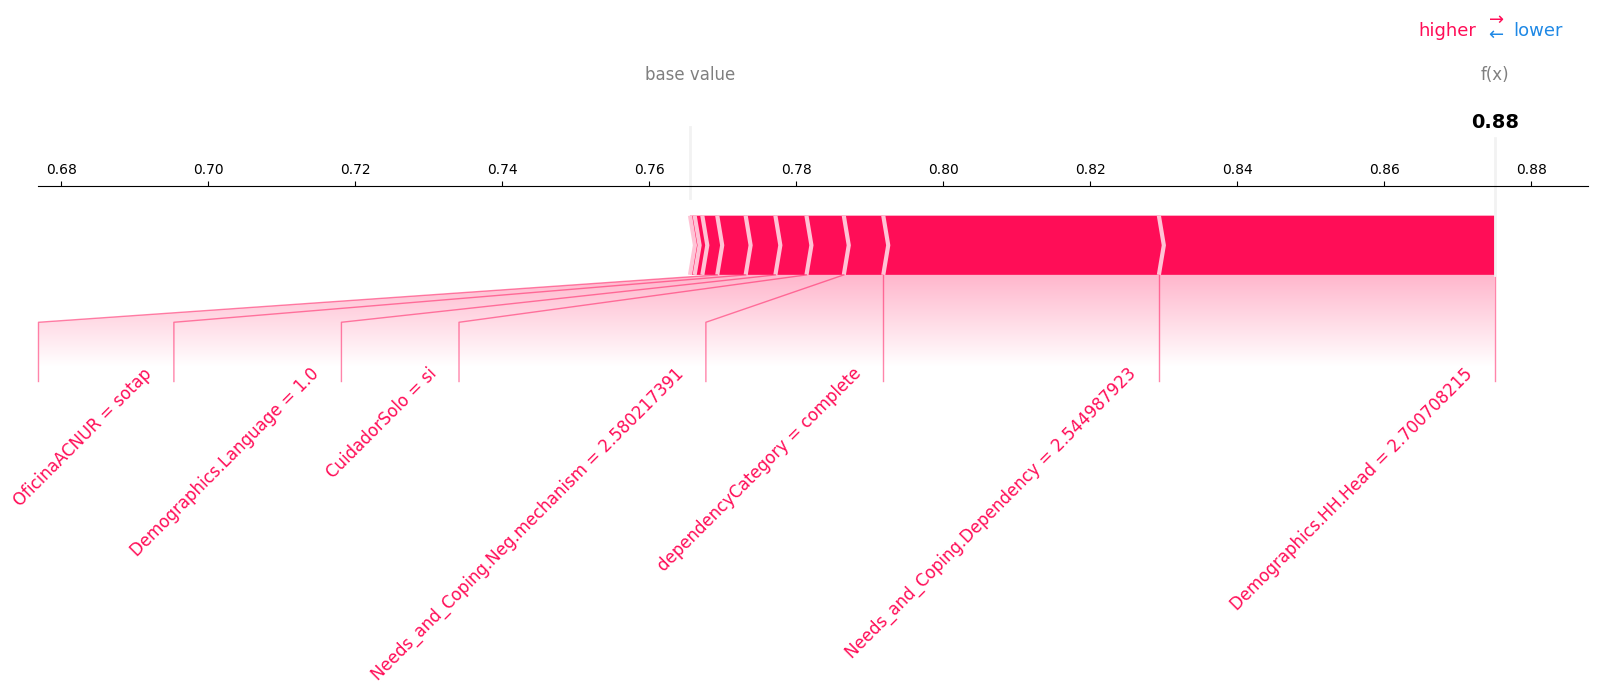

  0%|          | 0/1 [00:00<?, ?it/s]

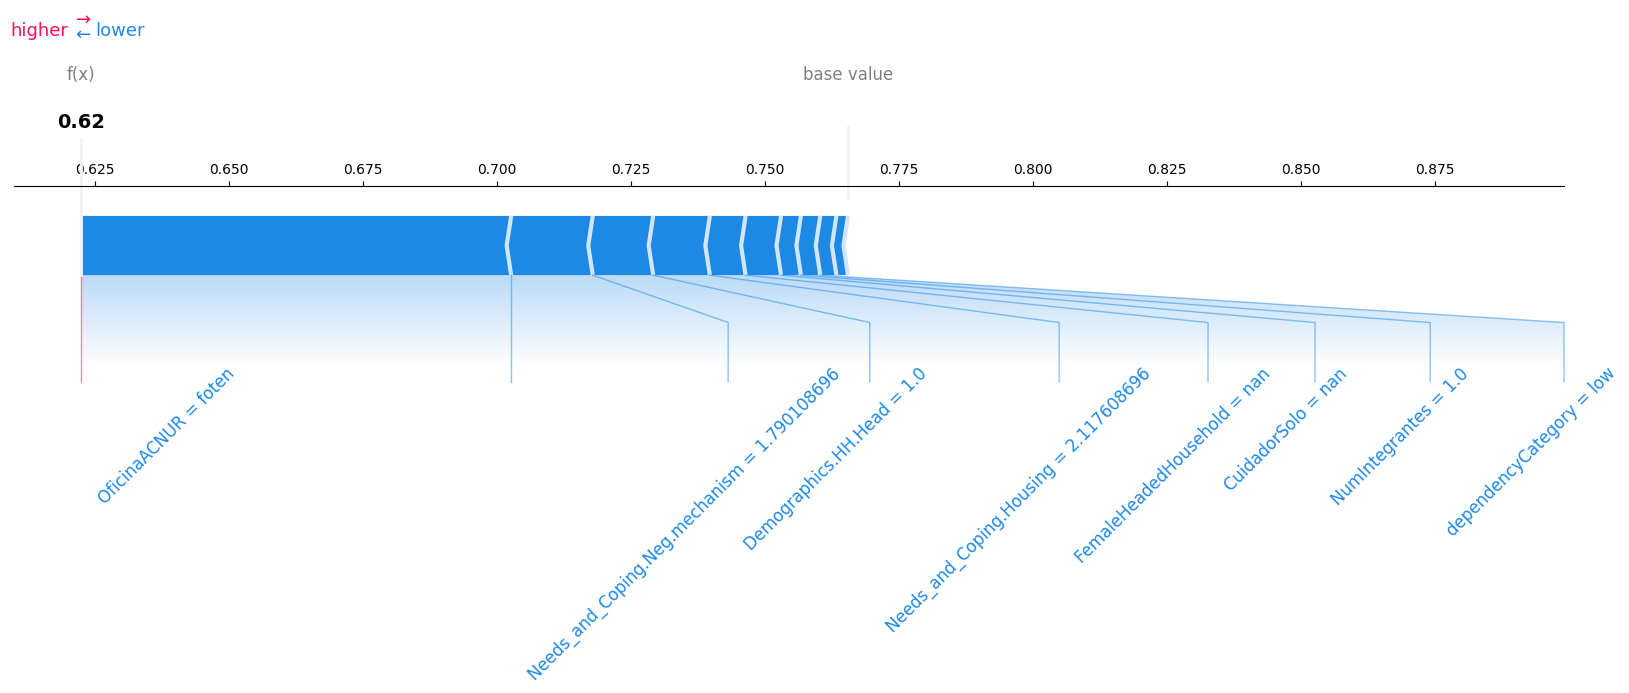

  0%|          | 0/1 [00:00<?, ?it/s]

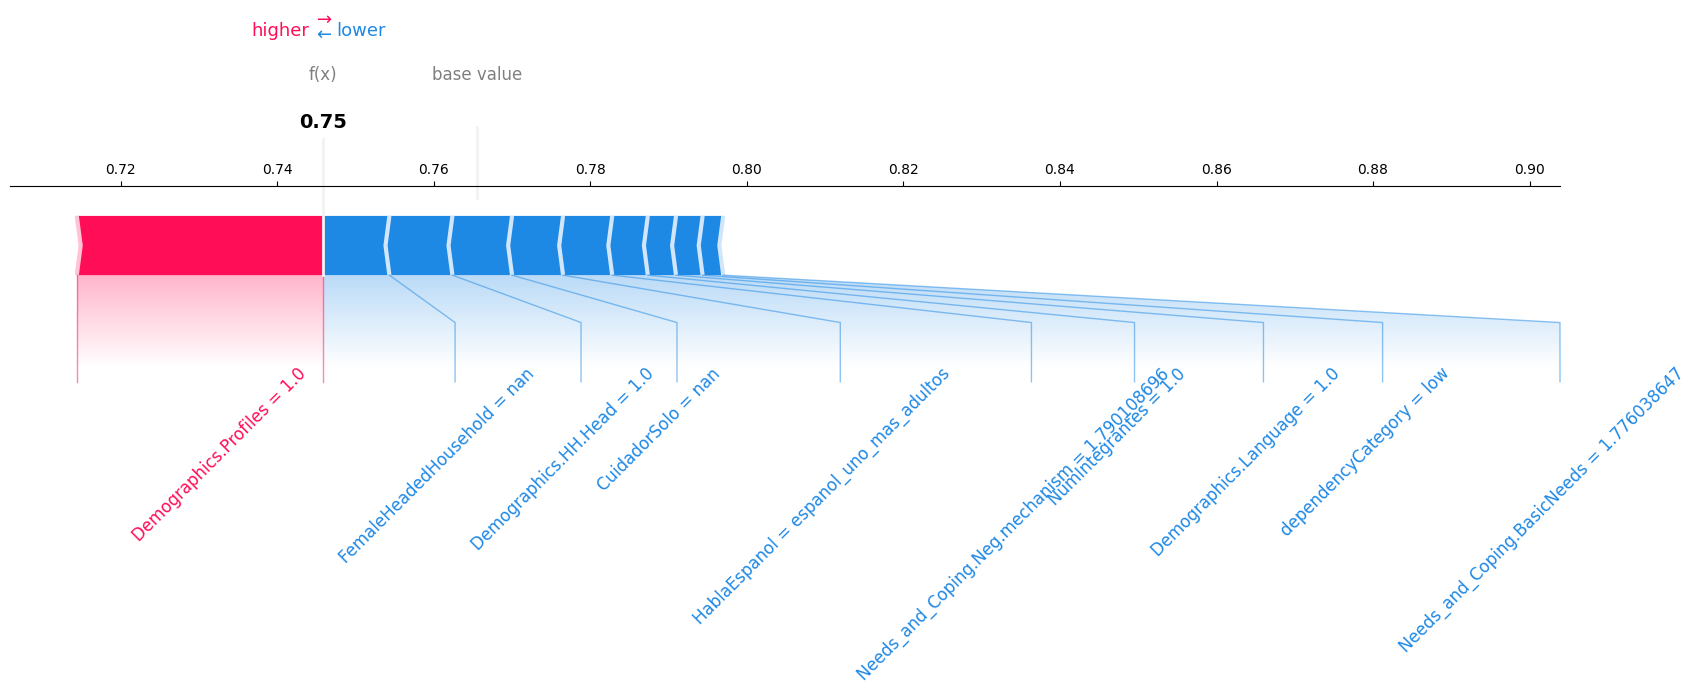

  0%|          | 0/1 [00:00<?, ?it/s]

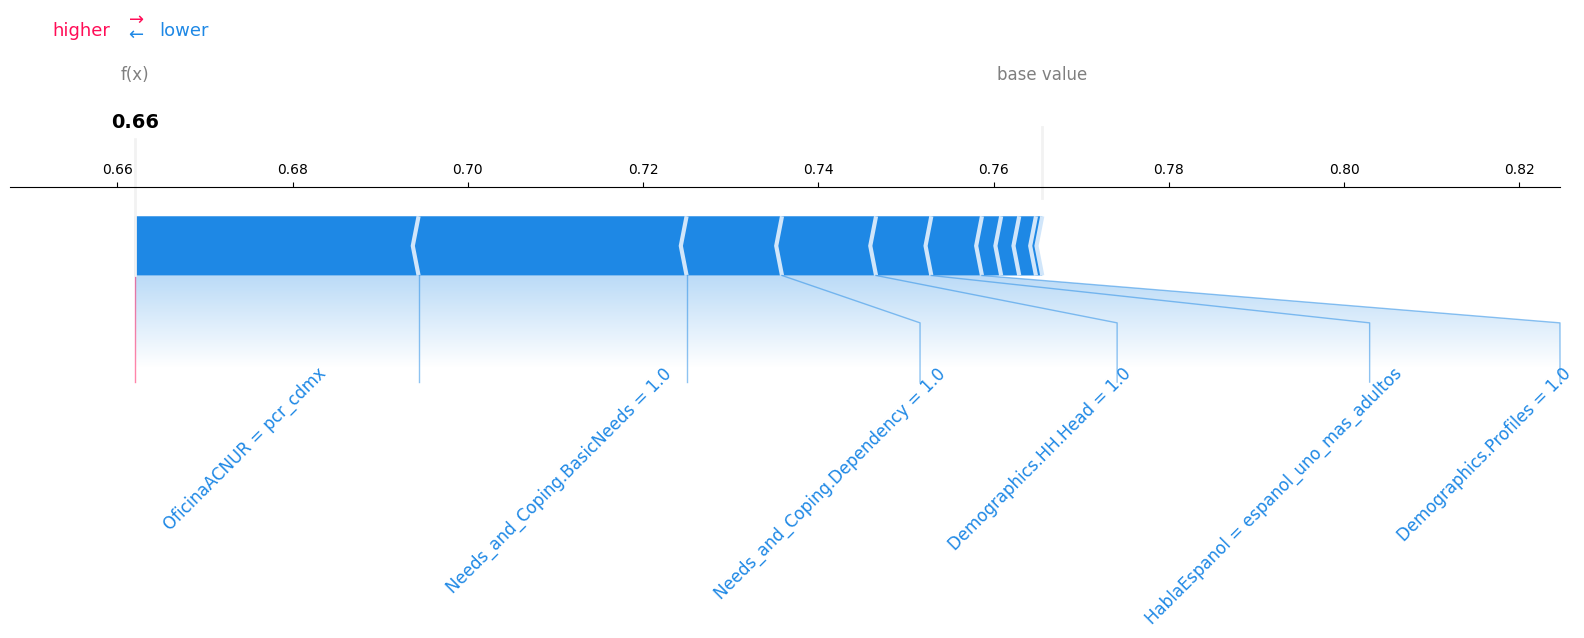

  0%|          | 0/1 [00:00<?, ?it/s]

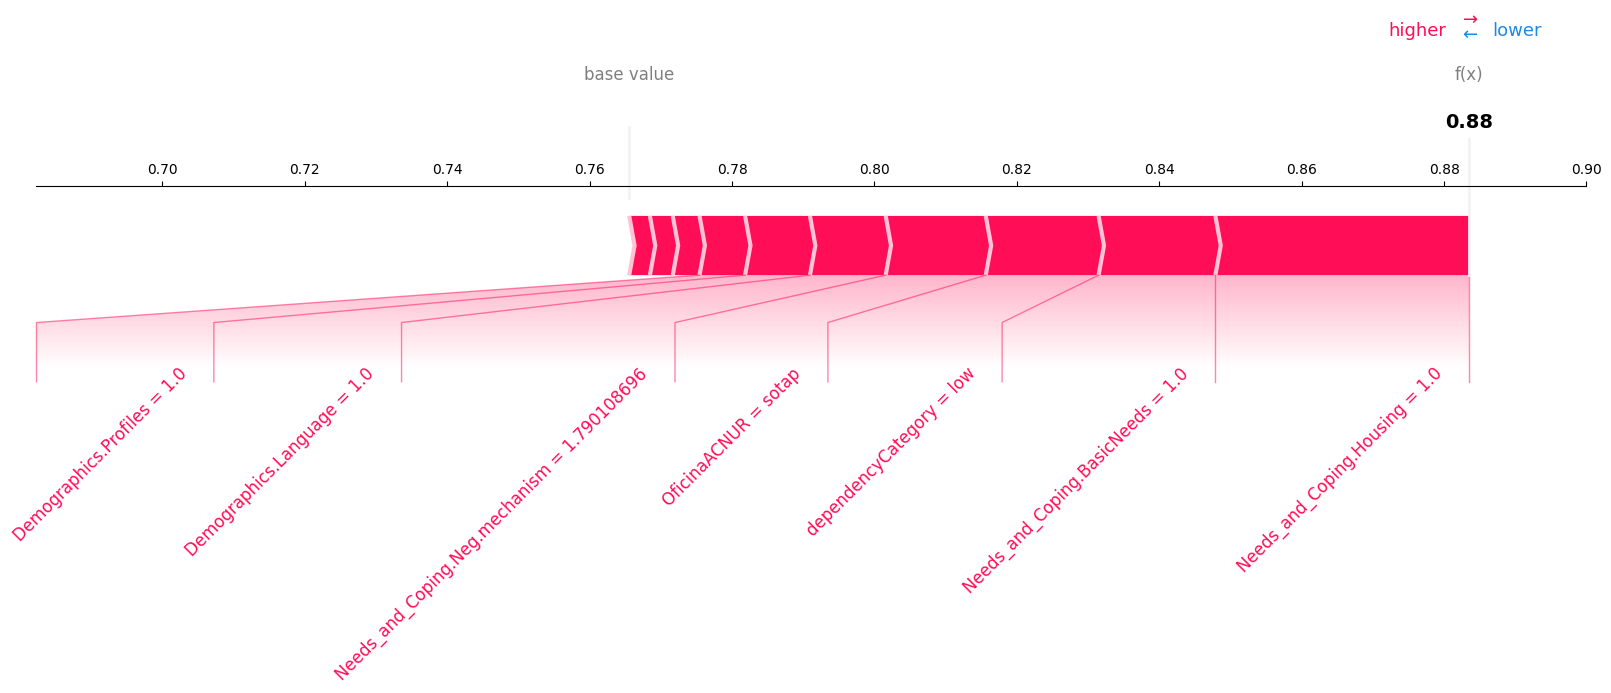

  0%|          | 0/1 [00:00<?, ?it/s]

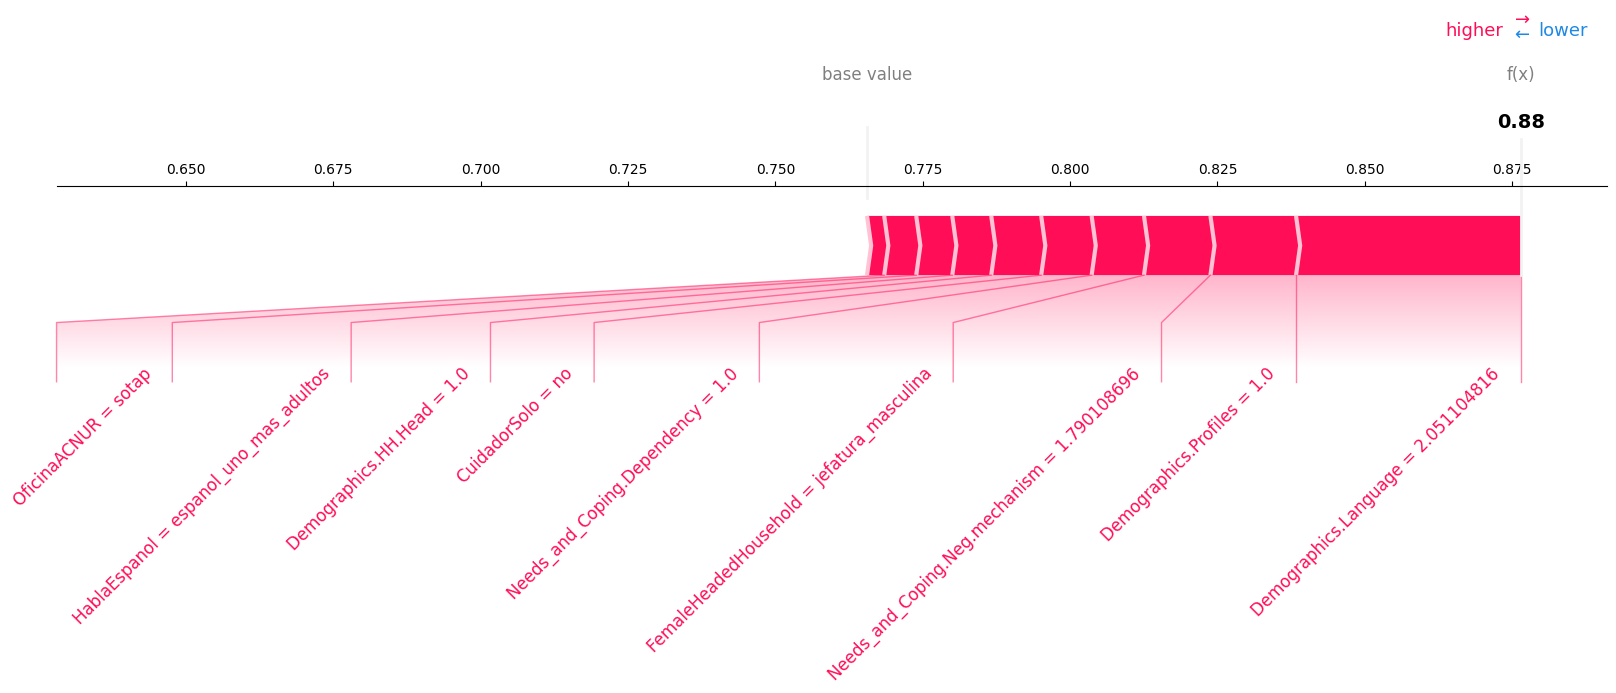

  0%|          | 0/1 [00:00<?, ?it/s]

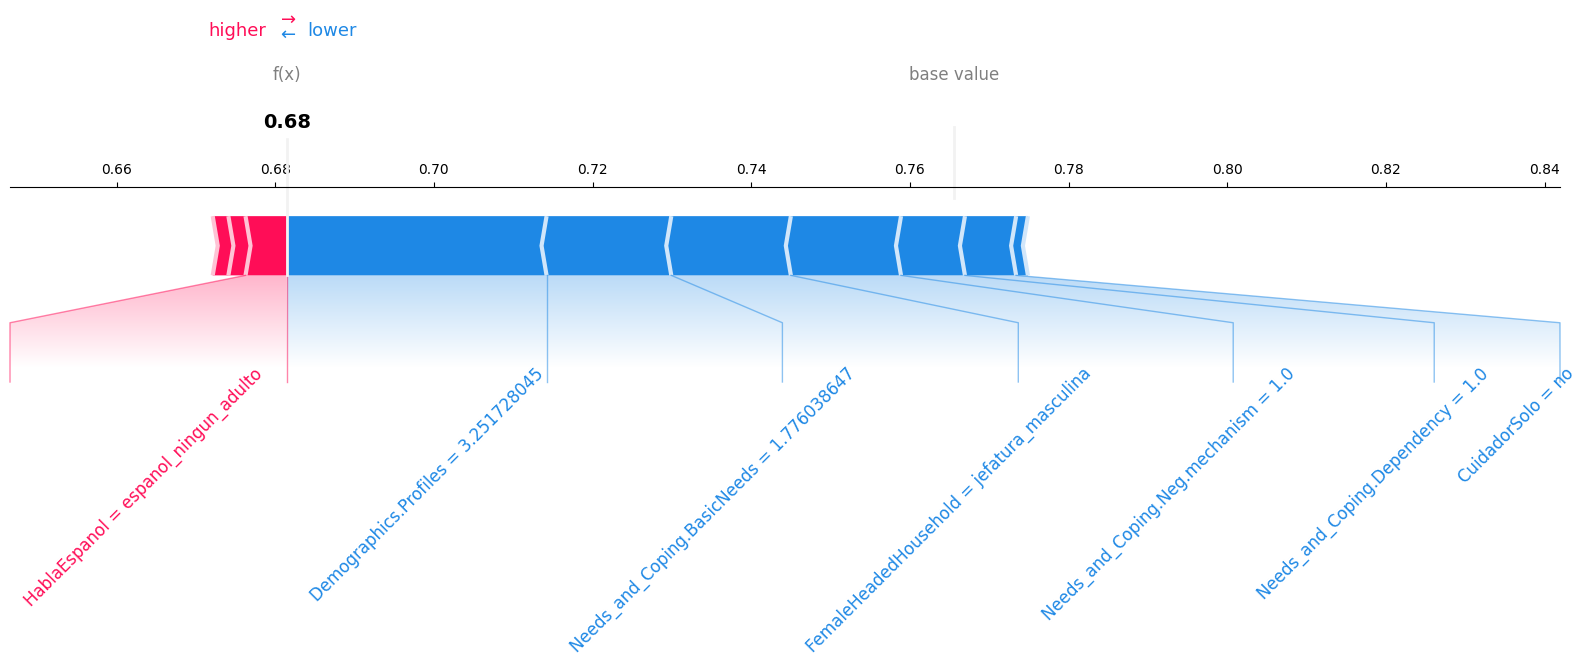

In [78]:
for i in range(10):
  # NEW single row of data
  new_row = Xx.iloc[[i]]

  # 6. Calculate the local importance scores
  shap_values = explainer.shap_values(new_row)

  shap.initjs()

  # Extract the base value as a single float
  base_val = explainer.expected_value
  # If explainer.expected_value is an array (for multi-output models), select the first element.
  # This assumes we want to explain the first class's prediction.
  if isinstance(base_val, (list, np.ndarray)):
      base_val = base_val[0]

  # Extract the SHAP values as a flat 1D array for this specific row
  if isinstance(shap_values, list):
      s_vals_2d = shap_values[0] # Assuming each element in the list is (num_samples, num_features)
      s_vals = s_vals_2d[0] # If there's only one sample, get its SHAP values
  else:
      # Here, shap_values is a 3D array (1, num_features, num_classes)
      # s_vals_2d will be (num_features, num_classes)
      s_vals_2d = shap_values[0]

  # Select the SHAP values for the first class (index 0) to get a 1D array
  s_vals = s_vals_2d[:, 0]

  # --- FIX STARTS HERE ---
  # The error occurs because s_vals (19 elements) and features_for_plot (18 elements) have different lengths.
  # This happens because shap_values were calculated for 'new_row' which still contained 'EligibilityTarget'.
  # We need to remove the SHAP value corresponding to 'EligibilityTarget' from `s_vals`.

  # Get the name of the target column
  target_column_name = 'EligibilityTarget'

  # Get the index of the target column in the original new_row DataFrame
  # This index corresponds to the position of its SHAP value in s_vals
  if target_column_name in new_row.columns:
      target_col_index = new_row.columns.get_loc(target_column_name)
      # Remove the SHAP value at this index
      s_vals_corrected = np.delete(s_vals, target_col_index)
  else:
      # If the target column is not in new_row (which implies it was handled upstream),
      # then s_vals should already have the correct length.
      s_vals_corrected = s_vals

  # 3. Plot the visualization using a 1D pandas Series for the row.
  # Ensure `features` matches the `s_vals` by dropping the 'EligibilityTarget' column,
  # as `s_vals` is calculated for the input features only.
  # This 'features_for_plot' already correctly excludes the target.
  features_for_plot = new_row.iloc[0].drop(target_column_name, errors='ignore')

  shap.force_plot(
      base_value=float(base_val),
      shap_values=s_vals_corrected,
      features=features_for_plot,
      matplotlib=True,       # Forces a static image instead of JS
      figsize=(20, 5),       # (Width, Height) in inches - adjust as needed
      text_rotation=45       # Tilts the labels so they don't overlap
  )